# Economics Lab: Logistic Regression & the Decision Boundary
## Application — Mortgage Default Risk (SOLUTION)

*Adapted from a machine-learning "decision boundary" exercise, re-cast as an economics / credit-risk problem.*


## Goals
In this lab you will:
- Build a small two-feature credit-risk dataset (Debt-to-Income ratio, Loan-to-Value ratio) and a binary outcome (mortgage **default** vs. **repaid**).
- Refresh how the sigmoid function turns a linear score into a probability.
- Derive and plot the **decision boundary** of a logistic regression classifier by hand, given its parameters.
- Interpret the boundary and the coefficients in economic terms.
- Extend the idea to a **non-linear** boundary using polynomial terms, and discuss when a linear boundary is/isn't appropriate for economic data.


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    """Numerically stable sigmoid / logistic function."""
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def plot_data(X, y, ax, pos_label="Default (y=1)", neg_label="Repaid (y=0)", s=90):
    """Scatter-plot a 2-feature binary-outcome dataset."""
    y = np.array(y).reshape(-1)
    pos = y == 1
    neg = y == 0
    ax.scatter(X[pos, 0], X[pos, 1], marker='x', s=s, c='crimson', linewidths=2, label=pos_label)
    ax.scatter(X[neg, 0], X[neg, 1], marker='o', s=s, facecolors='none',
               edgecolors='steelblue', linewidths=2, label=neg_label)
    ax.legend(loc='best')

def draw_vthresh(ax, x):
    """Shade g(z)<0.5 vs g(z)>=0.5 either side of z=x on a sigmoid plot."""
    ylim, xlim = ax.get_ylim(), ax.get_xlim()
    ax.fill_between([xlim[0], x], ylim[1], alpha=0.15, color='steelblue')
    ax.fill_between([x, xlim[1]], ylim[1], alpha=0.15, color='crimson')
    ax.axvline(x, color='k', ls='--', lw=1)
    ax.set_xlim(xlim); ax.set_ylim(ylim)

def plot_linear_boundary(w, b, ax, x_range=(0, 4), color='seagreen', label='Decision boundary'):
    """Plot w0*x0 + w1*x1 + b = 0 and shade the predicted-0 region."""
    x0 = np.linspace(x_range[0], x_range[1], 200)
    x1 = -(w[0] * x0 + b) / w[1]
    ax.plot(x0, x1, c=color, lw=2, label=label)
    ax.fill_between(x0, x1, ax.get_ylim()[0], alpha=0.12, color=color)
    return x0, x1


## 1. The dataset

Suppose a bank has six recent mortgage applicants:

| Applicant | DTI index $x_0$ | LTV index $x_1$ | Outcome $y$ |
|---|---|---|---|
| 1 | 0.5 | 1.5 | 0 (repaid) |
| 2 | 1.0 | 1.0 | 0 (repaid) |
| 3 | 1.5 | 0.5 | 0 (repaid) |
| 4 | 3.0 | 0.5 | 1 (default) |
| 5 | 2.0 | 2.0 | 1 (default) |
| 6 | 1.0 | 2.5 | 1 (default) |

- $x_0$ = **Debt-to-Income (DTI) index** — higher means more debt-service burden relative to income.
- $x_1$ = **Loan-to-Value (LTV) index** — higher means the loan is large relative to collateral value.
- $y=1$ = defaulted, $y=0$ = repaid.

In [2]:
X = np.array([[0.5, 1.5], [1.0, 1.0], [1.5, 0.5], [3.0, 0.5], [2.0, 2.0], [1.0, 2.5]])
y = np.array([0, 0, 0, 1, 1, 1]).reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (6, 2)
y shape: (6, 1)


### 1.1 Plot the data

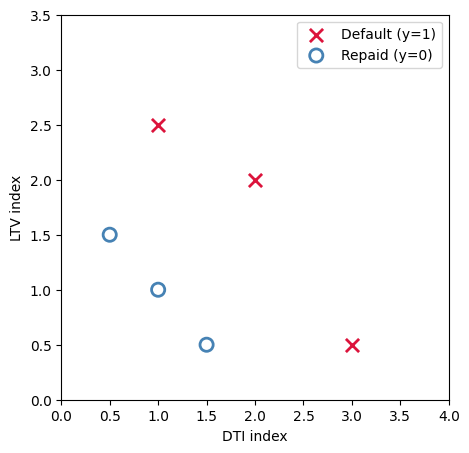

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plot_data(X, y, ax)
ax.set_xlabel("DTI index")
ax.set_ylabel("LTV index")
ax.axis([0, 4, 0, 3.5])
plt.show()


Visually, defaults (red X) cluster toward the upper-right — applicants with *both* high leverage indices — while repayments (blue circles) sit in the lower-left. A single straight line looks like it could separate the two groups reasonably well.

## 2. The logistic regression model

$$f(\mathbf{x}) = g(w_0 x_0 + w_1 x_1 + b), \qquad g(z) = \frac{1}{1+e^{-z}}$$

Fitted parameters: $b=-3,\ w_0=1,\ w_1=1$, so

$$f(\mathbf{x}) = g(x_0 + x_1 - 3)$$

$f(\mathbf{x})$ is the model's estimated **probability of default**.

### Refresher: from probability to a 0/1 decision

- predict $y=1$ (default) if $f(\mathbf{x}) \ge 0.5$
- predict $y=0$ (repaid) if $f(\mathbf{x}) < 0.5$

Since $g(z)\ge 0.5 \iff z\ge0$:
- predict $y=1$ if $w_0x_0+w_1x_1+b \ge 0$
- predict $y=0$ if $w_0x_0+w_1x_1+b < 0$

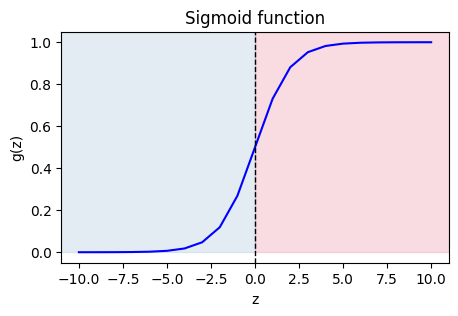

In [4]:
z = np.arange(-10, 11)

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(z, sigmoid(z), c="b")
draw_vthresh(ax, 0)
ax.set_title("Sigmoid function")
ax.set_xlabel("z")
ax.set_ylabel("g(z)")
plt.show()


As expected, $g(z)\ge 0.5$ exactly for $z\ge 0$ — confirming the threshold rule above.

## 3. Deriving and plotting the decision boundary

Setting $x_0+x_1-3=0$ gives the boundary $x_1 = 3-x_0$.

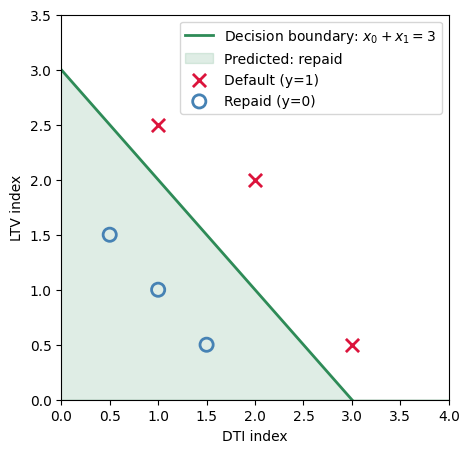

In [5]:
x0 = np.arange(0, 6)
x1_boundary = 3 - x0

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.plot(x0, x1_boundary, c="seagreen", lw=2, label="Decision boundary: $x_0+x_1=3$")
ax.fill_between(x0, x1_boundary, alpha=0.15, color="seagreen", label="Predicted: repaid")
plot_data(X, y, ax)
ax.axis([0, 4, 0, 3.5])
ax.set_xlabel("DTI index")
ax.set_ylabel("LTV index")
ax.legend(loc="upper right")
plt.show()


The line intersects the axes at $(3,0)$ and $(0,3)$ — anywhere on or above it the model predicts **default**; anywhere below it, **repayment**. Every training point in our small dataset falls on the side matching its label, so this linear boundary perfectly separates the six applicants.

**Short-answer discussion**

1. **What does the line represent economically?** It's the combination of DTI and LTV at which the model is exactly 50/50 on default — an *iso-risk* line. Every point on it has the same predicted default probability (0.5); points further into the shaded region have progressively lower default probability, and points further above the line have progressively higher default probability.

2. **Applicant 5** (DTI=2.0, LTV=2.0): $z = 2.0+2.0-3 = 1.0 > 0$, so the model predicts default — matching the observed outcome ($y=1$).

3. **Substitutability of leverage.** Because the boundary is linear with *equal* coefficients ($w_0=w_1=1$), the model treats one unit of extra DTI as exactly as risky as one unit of extra LTV — an applicant with (DTI=3, LTV=0.2) and one with (DTI=0.2, LTV=3) get the *same* predicted risk ($z=3.2-3=0.2$ either way). Economically that's a strong assumption: it says debt-service burden and collateral thinness are perfect substitutes for default risk, which real credit-risk research doesn't generally support (their effects, and their interaction, are usually estimated separately and often asymmetric). A model that fits $w_0 \ne w_1$, or adds an interaction term $x_0x_1$, relaxes this assumption.

## 4. Extension: a non-linear boundary

Now suppose the risk team instead fits $f(\mathbf{x}) = g(x_0^2 + x_1 - 1)$, i.e. default risk grows **quadratically** in DTI. Boundary: $x_1 = 1 - x_0^2$.

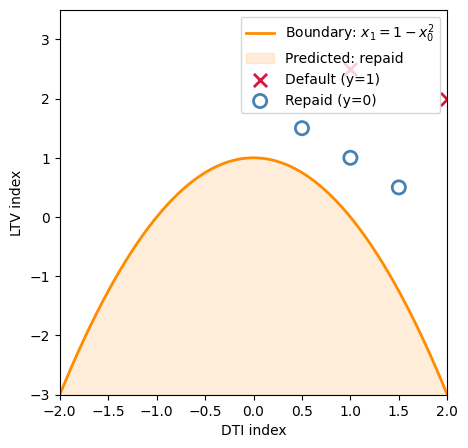

In [6]:
x0_nl = np.linspace(-2, 2, 200)
x1_nl_boundary = 1 - x0_nl**2

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.plot(x0_nl, x1_nl_boundary, c="darkorange", lw=2, label="Boundary: $x_1=1-x_0^2$")
ax.fill_between(x0_nl, x1_nl_boundary, -3, alpha=0.15, color="darkorange", label="Predicted: repaid")
plot_data(X, y, ax)
ax.axis([-2, 2, -3, 3.5])
ax.set_xlabel("DTI index")
ax.set_ylabel("LTV index")
ax.legend(loc="upper right")
plt.show()


**Comparison.** The linear boundary was a straight iso-risk line; this one is a downward-opening parabola. Economically, a quadratic term on DTI captures **accelerating risk**: once leverage crosses a threshold, each extra unit of DTI pushes default probability up *faster* than the linear model implies (a convex, "cliff-edge" effect — consistent with empirical findings that mortgage default risk rises sharply near payment-shock or negative-equity thresholds, not smoothly). Whether this shape is *justified* is an empirical question — it should be chosen because the data show that curvature (e.g. via a likelihood-ratio test comparing the linear and quadratic specifications), not merely because a curve fits training points more closely. Adding flexibility beyond what the relationship really has risks **overfitting**, discussed further in the Cheatsheet notebook.

## Wrap-up

You practiced:
- Encoding a small economic dataset for classification
- Refreshing the sigmoid / 0.5-threshold logic
- Deriving and plotting a **linear** decision boundary from logistic-regression coefficients, and reading it as an iso-risk line
- Interpreting the coefficients' economic meaning (substitutability of risk factors)
- Sketching a **non-linear** boundary and reasoning about when curvature is economically and statistically justified

➡️ See the **Cheatsheet** notebook for formulas (odds ratios, marginal effects) and the **Template** notebook to apply this workflow to a new economics classification problem.
